##### Main task
Ми хочемо зрозуміти, як користувачі з різних країн поводяться з часом:
– хто краще утримується \
– хто приносить більше цінності \
– де є проблеми продукту або локалізації 

Для цього треба:
> 1. Підготувати данні: очистка + створити InvoiceMonth
> 2. Визначити місяць входу користувача 
> 3. Обираємо топ країни
> 4. Рахуємо користувачів 
> 5. Рахуємо retention 
> 6. Будуємо heatmap

In [7]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt


In [2]:
df = pd.read_excel('Online Retail.xlsx') # !! треба змінити на свій шлях !!

In [3]:
# Data Cleaning 
df.drop_duplicates(inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['CustomerID'].notnull())]

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [28]:
# Створити InvoiceMonth

# def get_month(x): return dt.datetime(x.year, x.month, 1)

# df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

df["InvoiceDate"] =  pd.to_datetime(df["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()


In [30]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1


In [17]:
# Створити CohortMonth

# df["CohortMonth"] = (

#       .transform("min") # щоб отримати одного розміру мін по даті для кожного запису
#       .dt.to_period("M").dt.to_timestamp()
# )

grouping = df.groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min')

In [31]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1


In [19]:
# Формування час використання 
year_diff = df["InvoiceMonth"].dt.year - df["CohortMonth"].dt.year
month_diff = df["InvoiceMonth"].dt.month - df["CohortMonth"].dt.month

df["CohortIndex"] = year_diff * 12 + month_diff + 1


In [20]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1


In [ ]:
# Обираємо топ країни
top_countries = df['Country'].value_counts().head(5).index

df_geo = df[df["Country"].isin(top_countries)]

In [34]:
df_geo['Country'].value_counts()

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Name: count, dtype: int64

In [43]:
cohort_counts_geo = pd.pivot_table( 
        df_geo,
        index = ['Country','CohortMonth'], # обрати індекси
        columns = 'CohortIndex', # обрати колонку
        values = 'CustomerID', # обрати значення 
        aggfunc= "nunique" # aggregation
    
)

In [44]:
# Рахуємо retention
cohort_sizes_geo = cohort_counts_geo.iloc[:, 0]
cohort_sizes_geo
retention_geo = cohort_counts_geo.divide(cohort_sizes_geo, axis=0)


In [45]:
retention_geo

CohortIndex                  1         2         3         4         5   \
Country        CohortMonth                                                
EIRE           2010-12-01   1.0  0.666667  0.666667  1.000000  0.666667   
France         2010-12-01   1.0  0.466667  0.400000  0.466667  0.333333   
               2011-01-01   1.0  0.294118  0.352941  0.235294  0.235294   
               2011-02-01   1.0       NaN       NaN  0.500000  0.333333   
               2011-03-01   1.0  0.250000  0.250000       NaN  0.250000   
               2011-04-01   1.0  0.500000       NaN       NaN  0.250000   
               2011-05-01   1.0  0.400000  0.100000  0.300000  0.300000   
               2011-06-01   1.0       NaN  0.200000  0.600000       NaN   
               2011-07-01   1.0  0.333333  0.333333       NaN  0.333333   
               2011-08-01   1.0  0.200000  0.200000  0.200000  0.200000   
               2011-09-01   1.0  0.500000  0.666667       NaN       NaN   
               2011-10-01   1.0  0.200000  0.400000       NaN       NaN   
               2011-11-01   1.0       NaN       NaN       NaN       NaN   
               2011-12-01   1.0       NaN       NaN       NaN       NaN   
Germany        2010-12-01   1.0  0.500000  0.388889  0.666667  0.611111   
               2011-01-01   1.0  0.315789  0.368421  0.052632  0.315789   
               2011-02-01   1.0       NaN  0.250000  0.500000       NaN   
               2011-03-01   1.0  0.200000  0.400000       NaN  0.400000   
               2011-04-01   1.0  0.200000  0.400000  0.200000  0.200000   
               2011-05-01   1.0       NaN  0.200000  0.200000  0.400000   
               2011-06-01   1.0       NaN  0.666667  0.666667  0.333333   
               2011-07-01   1.0  0.285714  0.571429  0.285714  0.142857   
               2011-08-01   1.0  0.166667  0.666667  0.333333  0.166667   
               2011-09-01   1.0  0.166667  0.166667  0.166667       NaN   
               2011-10-01   1.0  0.444444  0.222222       NaN       NaN   
               2011-11-01   1.0       NaN       NaN       NaN       NaN   
               2011-12-01   1.0       NaN       NaN       NaN       NaN   
Spain          2010-12-01   1.0  0.750000  0.250000  0.500000  0.250000   
               2011-01-01   1.0       NaN  0.250000       NaN       NaN   
               2011-02-01   1.0  0.333333       NaN  0.333333  0.333333   
               2011-03-01   1.0       NaN  0.250000  0.500000       NaN   
               2011-04-01   1.0       NaN       NaN       NaN       NaN   
               2011-06-01   1.0  0.500000       NaN       NaN       NaN   
               2011-07-01   1.0       NaN       NaN  1.000000       NaN   
               2011-09-01   1.0  0.500000       NaN       NaN       NaN   
               2011-10-01   1.0       NaN       NaN       NaN       NaN   
               2011-11-01   1.0       NaN       NaN       NaN       NaN   
               2011-12-01   1.0       NaN       NaN       NaN       NaN   
United Kingdom 2010-12-01   1.0  0.354601  0.322699  0.373006  0.359509   
               2011-01-01   1.0  0.212291  0.259777  0.234637  0.332402   
               2011-02-01   1.0  0.188235  0.194118  0.285294  0.288235   
               2011-03-01   1.0  0.152745  0.260143  0.198091  0.224344   
               2011-04-01   1.0  0.209386  0.202166  0.216606  0.202166   
               2011-05-01   1.0  0.187500  0.171875  0.171875  0.207031   
               2011-06-01   1.0  0.177570  0.144860  0.238318  0.238318   
               2011-07-01   1.0  0.177515  0.195266  0.230769  0.278107   
               2011-08-01   1.0  0.226950  0.226950  0.241135  0.120567   
               2011-09-01   1.0  0.228261  0.300725  0.115942       NaN   
               2011-10-01   1.0  0.243827  0.111111       NaN       NaN   
               2011-11-01   1.0  0.117845       NaN       NaN       NaN   
               2011-12-01   1.0       NaN       NaN       NaN       NaN   

CohortIndex             

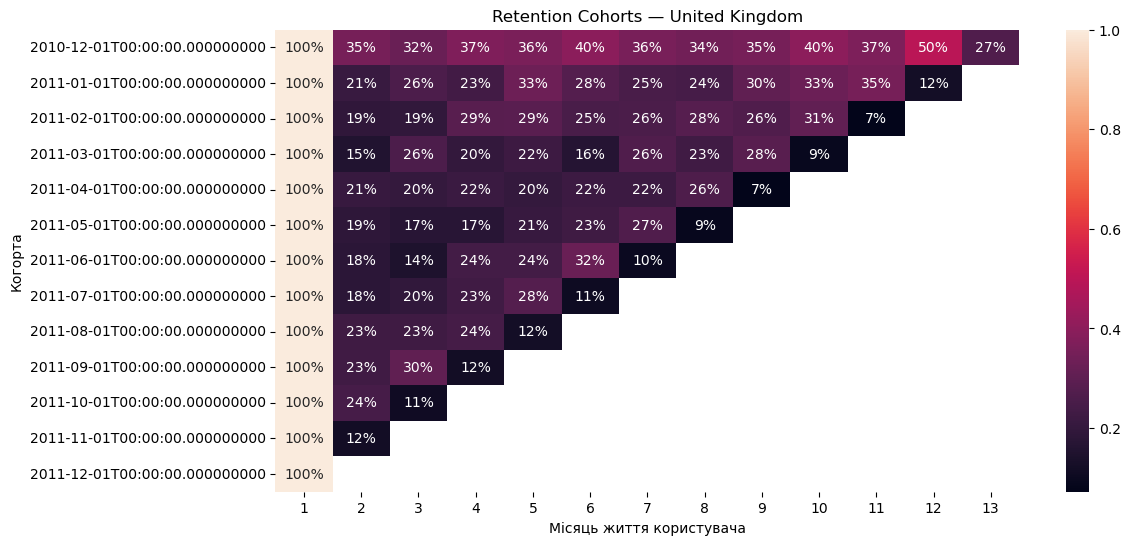

In [46]:
# Будуємо heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_geo.loc["United Kingdom"],
    annot=True,
    fmt=".0%",

)
plt.title("Retention Cohorts — United Kingdom")
plt.xlabel("Місяць життя користувача")
plt.ylabel("Когорта")
plt.show()


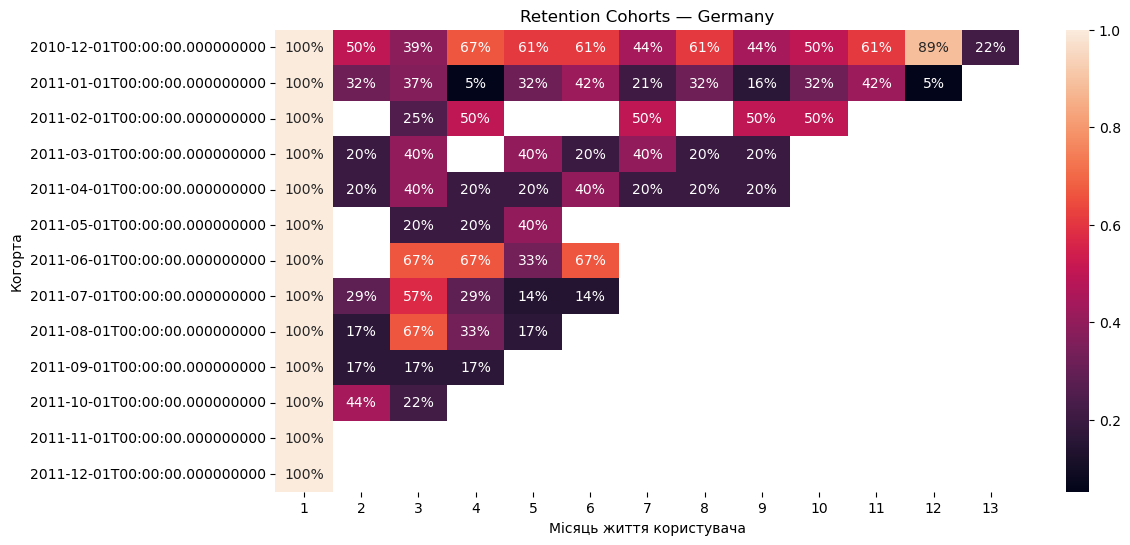

In [48]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_geo.loc["Germany"],
    annot=True,
    fmt=".0%",

)
plt.title("Retention Cohorts — Germany")
plt.xlabel("Місяць життя користувача")
plt.ylabel("Когорта")
plt.show()

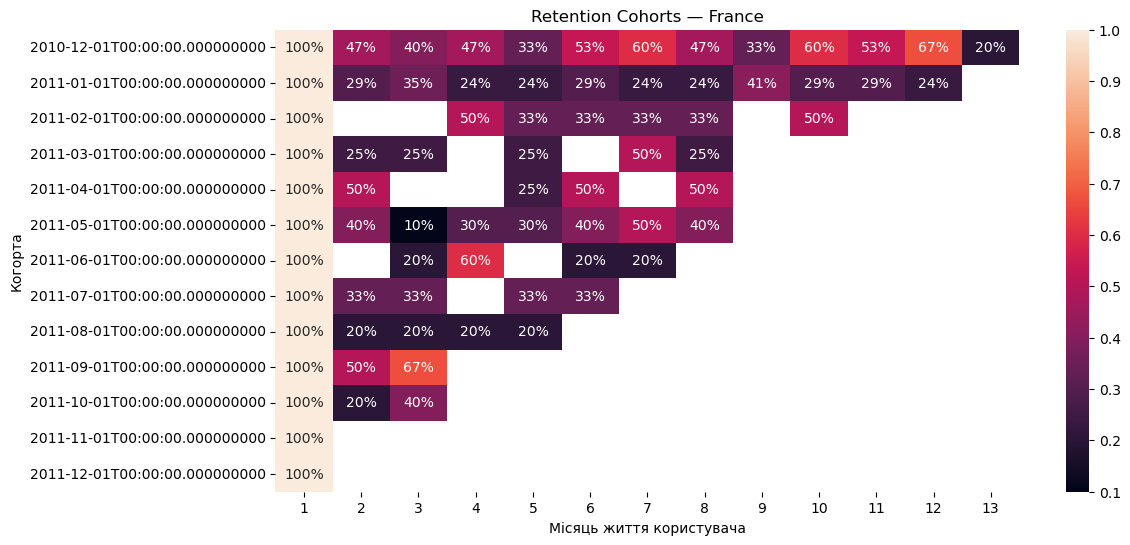

In [49]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_geo.loc["France"],
    annot=True,
    fmt=".0%",

)
plt.title("Retention Cohorts — France")
plt.xlabel("Місяць життя користувача")
plt.ylabel("Когорта")
plt.show()

Final result: порівняти retention/churn між топ 3 країни. Зробити гіпотези варіанти виправлення та як перевірити що стало краще ( метрика )

In [36]:
# Revenue/LTV
# revenue_geo = pd.pivot_table(
#     df_geo,
#     index=["Country", "CohortMonth"],
#     columns="CohortIndex",
#     values="Revenue",
#     aggfunc="sum"
# )
# revenue_geo

In [38]:
# LTV
# ltv_geo = arpu_geo.cumsum(axis=1)
# ltv_geo